In [10]:
import pandas as pd
import numpy as np
import datetime as dt
%pip install nbformat
import plotly.express as px
stock_df= pd.read_csv('Amazon.csv')
fig= px.line(title='Amazon.com, Inc. (AMZN) Adjusted Closing Price [$]')
fig.add_scatter(x=stock_df['Date'], y= stock_df['Adj Close'], name= 'Adj Close')

Note: you may need to restart the kernel to use updated packages.


In [11]:
# now So what I wanted to do next is I wanted to simply create a generic function that just performs financial data plotting. The reason is because I wanted to create a function one time. And then I'm going to call the function capstone project. Let me show you.
import sys
print(sys.executable)
!c:/Users/shann/AppData/Local/Python/pythoncore-3.14-64/python.exe -m pip install nbformat
import plotly.express as px
def plot_financial_data (df, title):  #df could be anything it could be amazon stock, JP morgan stock or else
    fig = px.line(title= title)

    for i in df.columns[1:]:                                      # I try to plot multiple plot on the same figure, the adj price, closing price everything in one graph, and 1 equal if we look the stock_df data for example data form all from open until adj price
        fig.add_scatter(x=df['Date'], y=df[i], name =i)
        fig.update_traces(line_width=5)
        fig.update_layout({'plot_bgcolor': 'white'})
    fig.show()

plot_financial_data(stock_df.drop(['Volume'], axis=1), 'Amazon.com, Inc. (AMZN), Stock Price [$]')

c:\Users\shann\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [12]:
plot_financial_data(stock_df.iloc[:,[0,5]],' Amazon.com, Inc. (AMZN) Trading Volume')

In [13]:
import pandas as pd
import numpy as np
import datetime as dt

JPM_df= pd.read_csv('JPM.csv')
JPM_df

def plot_financial_data (df, title):  #df could be anything it could be amazon stock, JP morgan stock or else
    fig = px.line(title= title)

    for i in df.columns[1:]:                                      # I try to plot multiple plot on the same figure, the adj price, closing price everything in one graph, and 1 equal if we look the stock_df data for example data form all from open until adj price
        fig.add_scatter(x=df['Date'], y=df[i], name =i)
        fig.update_traces(line_width=5)
        fig.update_layout({'plot_bgcolor': 'white'})
    fig.show()

plot_financial_data(JPM_df,'JP Morgan Chase and Co. Prices [$]')
plot_financial_data(JPM_df.iloc[:,[0,6]],'JPM Morgan Chase and Co. Trading Volume')




In [14]:
#now how to perform Data visualization for a Single stock
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
%pip install plotly
import plotly.express as px
%pip install nbformat

stock_df = pd.read_csv('Amazon.csv')
stock_df['Daily Return']= stock_df['Adj Close'].pct_change(1) * 100
stock_df

stock_df['Daily Return'].replace(np.nan, 0 , inplace= True)
stock_df.describe().round(2)
def percentage_return_classifier(percentage_return):
    if percentage_return> -0.3 and percentage_return <=0.3:
        return 'Insignificant Change'
    elif percentage_return> 0.3 and percentage_return <= 3:
        return 'Positive Change'
    elif percentage_return > -3 and percentage_return<=-0.3 :
        return 'Negative Change'
    elif percentage_return > 3 and percentage_return<=7:
        return 'Large Positive Change'
    elif percentage_return > -7 and percentage_return <= -3:
        return 'Large Negative Change'
    elif percentage_return> 7:
        return 'Bull Run'
    elif percentage_return<=-7:
        return 'Bear Sell Off'

stock_df['Trend']= stock_df['Daily Return'].apply(percentage_return_classifier)
stock_df


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


C:\Users\shann\AppData\Local\Temp\ipykernel_130892\3244801762.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  stock_df['Daily Return'].replace(np.nan, 0 , inplace= True)


,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return,Trend
0,1/2/2018,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,NaN,NaN
1,1/3/2018,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531,Positive Change
2,1/4/2018,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601,Positive Change
3,1/5/2018,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252,Positive Change
4,1/8/2018,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468,Positive Change
...,...,...,...,...,...,...,...,...,...
1245,12/12/2022,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800,Positive Change
1246,12/13/2022,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457,Positive Change
1247,12/14/2022,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886,Negative Change
1248,12/15/2022,89.889999,89.970001,87.470001,88.449997,84802900,88.449997,-3.417782,Large Negative Change


In [15]:
#PERFORM DATA VISUALIZATION FOR MULTIPLE STOCKS

close_price_df= pd.read_csv('stock_prices.csv')
close_price_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,19.898500,69.512543,75.620926,14.121004,27.855856,71.443314,45.640057,54.709999,20.879053,61.941517
1,1/3/2014,19.822001,69.473892,75.956062,13.835152,27.652653,72.086861,45.992889,54.560001,20.920183,61.872295
2,1/6/2014,19.681499,68.561180,75.327690,13.923512,27.960960,72.463608,46.259468,57.200001,20.940746,62.018425
3,1/7/2014,19.901501,68.785461,75.662811,13.996271,28.500000,74.001869,45.726311,57.919998,21.070980,62.618301
4,1/8/2014,20.096001,68.947906,74.850121,13.965082,28.559309,73.899841,46.157543,58.230000,21.214928,61.710812
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,90.550003,233.059998,437.049988,42.500000,93.309998,177.839996,134.210007,114.709999,52.160000,152.470001
2253,12/13/2022,92.489998,235.490005,437.190002,42.540001,95.629997,179.210007,134.080002,120.150002,53.070000,152.240005
2254,12/14/2022,91.580002,234.479996,438.440002,42.820000,95.070000,179.759995,133.410004,121.589996,54.480000,152.839996
2255,12/15/2022,88.449997,230.660004,429.790008,42.380001,90.860001,177.490005,130.100006,116.150002,53.610001,151.110001


,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1/3/2014,0.996155,0.999444,1.004432,0.979757,0.992705,1.009008,1.007731,0.997258,1.001970,0.998882
2,1/6/2014,0.989095,0.986314,0.996122,0.986014,1.003773,1.014281,1.013572,1.045513,1.002955,1.001242
3,1/7/2014,1.000151,0.989540,1.000554,0.991167,1.023124,1.035812,1.001890,1.058673,1.009192,1.010926
4,1/8/2014,1.009925,0.991877,0.989807,0.988958,1.025253,1.034384,1.011338,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,4.550594,3.352776,5.779485,3.009701,3.349744,2.489246,2.940619,2.096692,2.498198,2.461515
2253,12/13/2022,4.648089,3.387734,5.781336,3.012534,3.433030,2.508422,2.937770,2.196125,2.541782,2.457802
2254,12/14/2022,4.602357,3.373204,5.797866,3.032362,3.412927,2.516121,2.923090,2.222446,2.609314,2.467489
2255,12/15/2022,4.445058,3.318250,5.683480,3.001203,3.261792,2.484347,2.850566,2.123012,2.567645,2.439559


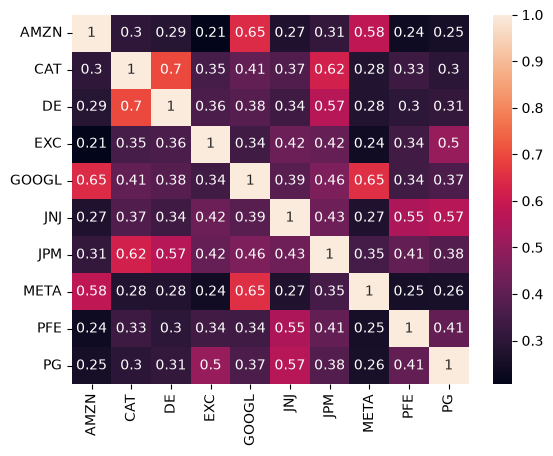

In [29]:
daily_returns_df=close_price_df.iloc[:,1:].pct_change()*100
daily_returns_df.replace(np.nan,0, inplace=True)
daily_returns_df   #I perform this calculation on all stock except for the first column which is date

daily_returns_df.insert(0,'Date',close_price_df['Date'])
daily_returns_df # this is to insert the date if we dont have date

plot_financial_data(daily_returns_df, 'Percentage Daily Returns [%]') #to plot the percentage daily returns
plot_financial_data(close_price_df, 'Adjusted Closing Prices []') # to plot adjusted closing price

#using plot histogram for stock daily returns using plotly express and comparing META to JNJ Daily returns histograms

fig= px.histogram(daily_returns_df.drop(columns=['Date']))
fig.update_layout({'plot_bgcolor':'white'})

#show the correlation between daily returns
plt.Figure(figsize=(10,8))
sns.heatmap(daily_returns_df.drop(columns=['Date']).corr(),annot=True);
#by using the correlation map we see if annot=False it means we will lose the number, and from the map we see there is a strong positive correlation between caterpillar and John Deere



#function to scale stock prices based on their initial starting price with the objection to set all prices to star at a value of 1

def price_scaling(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns[1:]:
        scaled_prices_df[i]= raw_prices_df[i]/raw_prices_df[i][0]
    return scaled_prices_df
price_scaling(close_price_df)

In [ ]:
#RANDOM PORTFOLIO WEIGHTS GENERATION
#assume we have $1M and we want to allocate into 4 following stock : AMZN, JPM, JNJ, PG
#we can use random() method to generate random portfolio weights with every code run

import random
random.random()  # every time if we run the syntax it will give us a different number

0.44321080192582973

In [ ]:
# so what we need, we need to define which random number that can fit in for our weight and if we sum up it give us equal to 1

def generate_portfolio_weights(n):   #n here indicate how many weights i need to get
    weights=[]
    for i in range(n):
        weights.append(random.random())
    weights = weights/np.sum(weights) 
    return weights
weights = generate_portfolio_weights(4)
print(weights)     #every time we run we will get the different number it is really important 


#what happen if we have 10 options, we can say

weights=generate_portfolio_weights(10)
print(weights)
sum(weights) #check whether it equal to 1 or not

[0.36959498 0.11466476 0.32433364 0.19140662]
[0.06254419 0.08776352 0.0825899  0.09495718 0.02986435 0.12424638
 0.19504821 0.17032627 0.03386607 0.11879394]


np.float64(0.9999999999999999)

In [61]:
#ASSET ALLOCATION
#the idea = Initial investment*weights*scaled up price
#assume we have 10 stocks with weights from below, and assume initial investment=$1M

weights=[0.032266, 0.094461, 0.117917, 0.132624, 0.145942, 0.128299, 0.10009, 0.007403, 0.088581, 0.152417]

close_price_df  # we have the adjusted close price from our 10 stocks now we need to scaled it

#we need to define price scaling
def price_scaling(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns[1:]:
        scaled_prices_df[i]= raw_prices_df[i]/raw_prices_df[i][0]
    return scaled_prices_df
price_scaling(close_price_df)

portfolio_df= close_price_df.copy()
scaled_df= price_scaling(portfolio_df)
scaled_df

#so the scaled price done, now how we can calculate each defined weight to the each scaled data price in each date
#use enumerate() method

initial_investment=1000000
for i, stock in enumerate(scaled_df.columns[1:]):
    portfolio_df[stock]= weights[i]*scaled_df[stock]*initial_investment
portfolio_df.round(1)




,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,32266.0,94461.0,117917.0,132624.0,145942.0,128299.0,100090.0,7403.0,88581.0,152417.0
1,1/3/2014,32142.0,94408.5,118439.6,129939.3,144877.4,129454.7,100863.8,7382.7,88755.5,152246.7
2,1/6/2014,31914.1,93168.2,117459.8,130769.2,146492.7,130131.3,101448.4,7739.9,88842.7,152606.2
3,1/7/2014,32270.9,93473.0,117982.3,131452.5,149316.8,132893.7,100279.2,7837.4,89395.3,154082.3
4,1/8/2014,32586.3,93693.7,116715.1,131159.6,149627.5,132710.5,101224.9,7879.3,90006.0,151849.3
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,146829.5,316706.6,681499.5,399158.6,488868.4,319367.8,294326.5,15521.8,221292.8,375176.8
2253,12/13/2022,149975.2,320008.7,681717.8,399534.3,501023.3,321828.1,294041.4,16257.9,225153.6,374610.9
2254,12/14/2022,148499.6,318636.2,683667.0,402164.0,498089.4,322815.8,292572.1,16452.8,231135.6,376087.2
2255,12/15/2022,143424.3,313445.2,670178.9,398031.6,476032.4,318739.3,285313.2,15716.7,227444.6,371830.3


In [69]:
#assume we have an initial investment of x=1M
#we can create a function that based on below criteria
    #1) stock closing prices
    #2)random weights
    #3) initial investment
#this function will generate
    #a) daily value(position) of each individual stock over the specified time period
    #b) total daily value of portfolio
    #c) percentage daily return

def asset_allocation(df, weights, initial_investment):
    portfolio_df = df.copy()

    # we scaled the stock price using price scaling, so we need to define it before we execute it( in case i havent define it)
    scaled_df = price_scaling(df)
  
    for i, stock in enumerate(scaled_df.columns[1:]):
        portfolio_df[stock] = scaled_df[stock] * weights[i] * initial_investment

    # Sum up all values and place the result in a new column titled "portfolio value [$]" 
   
    portfolio_df['Portfolio Value [$]'] = portfolio_df[portfolio_df != 'Date'].sum(axis = 1, numeric_only = True)
            
    # Calculate the portfolio percentage daily return and replace NaNs with zeros
    portfolio_df['Portfolio Daily Return [%]'] = portfolio_df['Portfolio Value [$]'].pct_change(1) * 100 
    portfolio_df.replace(np.nan, 0, inplace = True)
    
    return portfolio_df

#here we ignore the column date
n = len(close_price_df.columns)-1

# we try to generate the random weight
print('Number of stocks under consideration = {}'.format(n))
weights = generate_portfolio_weights(n).round(6)
print('Portfolio weights = {}'.format(weights))

#call function
portfolio_df = asset_allocation(close_price_df, weights, 1000000)
portfolio_df.round(2)

# Plot the portfolio percentage daily return
plot_financial_data(portfolio_df[['Date', 'Portfolio Daily Return [%]']], 'Portfolio Percentage Daily Return [%]')

# Plot each stock position in our portfolio over time
plot_financial_data(portfolio_df.drop(['Portfolio Value [$]', 'Portfolio Daily Return [%]'], axis = 1), 'Portfolio positions [$]')

# Plot the total daily value of the portfolio (sum of all positions)
plot_financial_data(portfolio_df[['Date', 'Portfolio Value [$]']], 'Total Portfolio Value [$]')


Number of stocks under consideration = 10
Portfolio weights = [0.008828 0.00999  0.184332 0.141955 0.101982 0.23468  0.036479 0.076843
 0.163509 0.041401]


In [70]:
#Sharpe ratio
#before we learn about monte carlo lets we define of sharpe ratio
#in case of sharpe ratio calculation we can use engine simulation function
#the input of the function are
    #1)portfolio weights
    #2) initial investment
# The function performs asset allocation and calculates portfolio statistical metrics including Sharpe ratio
# The function returns: 
    #1) Expected portfolio return 
    #2) Expected volatility 
    #3) Sharpe ratio 
    #4) Return on investment 
    #5) Final portfolio value in dollars

def simulation_engine(weights, initial_investment):
    portfolio_df = asset_allocation(close_price_df, weights, initial_investment)     # Perform asset allocation using random weights

    #Calculate the ROI

    return_on_investment = ((portfolio_df['Portfolio Value [$]'][-1:] - 
                                 portfolio_df['Portfolio Value [$]'][0])/ 
                                 portfolio_df['Portfolio Value [$]'][0]) * 100

    # Daily change of every stock in the portfolio (Note that we dropped the date, portfolio daily worth and daily % returns) 
    portfolio_daily_return_df = portfolio_df.drop(columns = ['Date', 'Portfolio Value [$]', 'Portfolio Daily Return [%]'])
    portfolio_daily_return_df = portfolio_daily_return_df.pct_change(1) 
      
    # Portfolio Expected Return formula, 252 because of we have 252 trading days in 1 year
    expected_portfolio_return = np.sum(weights * portfolio_daily_return_df.mean() ) * 252

    covariance = portfolio_daily_return_df.cov() * 252 
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))

    rf= 0.03     #rf= risk free rate, we can use 10 year treasury US Bond

#Calculate sharpe Ratio
    sharpe_ratio = (expected_portfolio_return - rf)/expected_volatility 
    return expected_portfolio_return, expected_volatility, sharpe_ratio, portfolio_df['Portfolio Value [$]'][-1:].values[0], return_on_investment.values[0]

#now we test the simulation engine

initial_investment = 1000000
portfolio_metrics = simulation_engine(weights, initial_investment)
print('Expected Portfolio Annual Return = {:.2f}%'.format(portfolio_metrics[0] * 100))
print('Portfolio Standard Deviation (Volatility) = {:.2f}%'.format(portfolio_metrics[1] * 100))
print('Sharpe Ratio = {:.2f}'.format(portfolio_metrics[2]))
print('Portfolio Final Value = ${:.2f}'.format(portfolio_metrics[3]))
print('Return on Investment = {:.2f}%'.format(portfolio_metrics[4]))

Expected Portfolio Annual Return = 15.71%
Portfolio Standard Deviation (Volatility) = 17.00%
Sharpe Ratio = 0.75
Portfolio Final Value = $3226410.64
Return on Investment = 222.64%


In [75]:
#MONTE CARLO SIMULATION
#Monte carlo simulation works by running several trials with random input generated from an underlying distribution and observing the outcomes.
# its applied in finance, game theory, physics, etc.
#here we use randomly generated portfolio weights as an input and observe portfolio return, risk, and sharpe ratio as the output
# after running monte carlo simulation, pick the optimal portfolio that delivers the highest sharpe ratio

sim_runs=10
initial_investment=1000000

#now we need to make a placeholder to store all weights, sharpe ratios, volatility values, ROI, and final portfolio values with the help of numpy

weights_runs= np.zeros((sim_runs,n))
sharpe_ratios_runs=np.zeros(sim_runs)
expected_portfolio_return=np.zeros(sim_runs)
volatility_runs=np.zeros(sim_runs)
return_on_investent=np.zeros(sim_runs)
final_values_runs=np.zeros(sim_runs)

for i in range(sim_runs):
    weights=generate_portfolio_weights(n)              # generate random weights
    weights_runs[i,:]= weights                        #store the weights

#call ''simulation_engine'' function and store sharpe ratio, return and volatility
#note that asset allocation is performed using the ''asset_allocation'' function
    expected_portfolio_return[i], volatility_runs[i], sharpe_ratios_runs[i], final_values_runs[i], return_on_investent[i]=simulation_engine(weights, initial_investment)

    print('Simulation Run={}'.format(i))
    print('weights={}, Final Value =${:.2f}, Sharpe Ratio={:.2f}'.format(weights_runs[i].round(3), final_values_runs[i],sharpe_ratios_runs[i]))



Simulation Run=0
weights=[0.127 0.233 0.031 0.077 0.06  0.017 0.194 0.047 0.171 0.043], Final Value =$3160510.94, Sharpe Ratio=0.70
Simulation Run=1
weights=[0.065 0.158 0.156 0.166 0.052 0.081 0.072 0.077 0.108 0.066], Final Value =$3362769.53, Sharpe Ratio=0.75
Simulation Run=2
weights=[0.075 0.136 0.017 0.128 0.081 0.098 0.141 0.103 0.08  0.141], Final Value =$2931483.49, Sharpe Ratio=0.70
Simulation Run=3
weights=[0.036 0.227 0.012 0.102 0.048 0.154 0.176 0.116 0.087 0.042], Final Value =$2892676.53, Sharpe Ratio=0.67
Simulation Run=4
weights=[0.104 0.009 0.109 0.151 0.045 0.134 0.107 0.162 0.029 0.149], Final Value =$3126452.54, Sharpe Ratio=0.72
Simulation Run=5
weights=[0.168 0.017 0.082 0.081 0.121 0.079 0.197 0.09  0.107 0.059], Final Value =$3251042.84, Sharpe Ratio=0.72
Simulation Run=6
weights=[0.132 0.05  0.144 0.086 0.037 0.126 0.15  0.096 0.059 0.12 ], Final Value =$3327529.04, Sharpe Ratio=0.76
Simulation Run=7
weights=[0.169 0.002 0.151 0.046 0.117 0.111 0.103 0.106 0.

In [ ]:
sharpe_ratios_runs
#how to record the minimum or max of sharpe ratio
sharpe_ratios_runs.min()
sharpe_ratios_runs.max()

#by increasing the number of simulation runs, I have been able to explore the search space, it means more random allocations, and perhaps able to achieve a higher sharpe ratio

np.float64(0.7589609285057624)